# Optimization Comparisons
## By: Sandra Afrifa, Mussa Hassen, Andi Mellyn

Original dataset: https://www.kaggle.com/datasets/noeyislearning/framingham-heart-study

Framingham heart study dataset (over 4,240 records,16 columns) predict if patient has risk of future coronary heart disease (binary).



# Cost Functions and Model Setup
- We model the 10-year risk of coronary heart disease (TenYearCHD) using:

    1. **Logistic Regression**
    2. **Ridge Logistic Regression**

Let $X \in \mathbb{R}^{n \times d}$ be the feature matrix (standardized, with a bias column),
$y \in \{0,1\}^n$ the labels, and $w \in \mathbb{R}^d$ the parameter vector.

### Logistic regression model

The logistic function is:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}.
$$

Predicted probability for sample $i$:

$$
p_i = \sigma(x_i^\top w).
$$

The logistic loss is:

$$
J_{\text{log}}(w)
= -\frac{1}{n} \sum_{i=1}^n
\left[
y_i \log(p_i) + (1 - y_i)\log(1 - p_i)
\right].
$$

### Ridge logistic regression

We add an L2 penalty on all weights **except the bias term**:

$$
J_{\text{ridge}}(w)
= J_{\text{log}}(w)
+ \frac{\alpha}{2}
\|w_{\text{no-bias}}\|_2^2.
$$


- $\alpha$ controls the strength of regularization,
- $w_{\text{no-bias}}$ is the vector of weights excluding the last (bias) term.


### Data cleaning

Omitted 2 columns, education and glucose, because they weren't important for predicting heart disease and had many NA values dropping the total columns to 14. Omitted rows with NA values dropping the total number of records to 4090.

\* *preserving all the data wasn't important for testing optimization algorithms*

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
# model scripts
from models.logistic import logistic_loss, logistic_grad, logistic_hess
from models.logistic_ridge import logistic_ridge_loss, logistic_ridge_grad, logistic_ridge_hess

# algorithm scripts
from algorithms.gradient_descent import gradient_descent
from algorithms.adam import adam
from algorithms.newton import newton
from algorithms.bfgs import bfgs
from algorithms.conjugate_gradient import conjugate_gradient

In [5]:
# loading dataset

df = pd.read_csv("../data/framingham_cleaned.csv")
df.head()

,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,TenYearCHD
0,1,39,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,0
1,0,46,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,0
2,1,48,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,0
3,0,61,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,1
4,0,46,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,0


In [6]:
feature_cols = ["male", "age", "currentSmoker", "cigsPerDay", "BPMeds",
    "prevalentStroke", "prevalentHyp", "diabetes",
    "totChol", "sysBP", "diaBP", "BMI", "heartRate"]

target_col = "TenYearCHD"

In [8]:
# scale features, add a bias column
x_raw = df[feature_cols].to_numpy()
y = df[target_col].to_numpy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(x_raw)

ones = np.ones((X_scaled.shape[0], 1))
X = np.hstack([X_scaled, ones])

print("X shape:", X.shape, "| y shape:", y.shape)

X shape: (4090, 14) | y shape: (4090,)


In [10]:
# data split into testing and training sets
# 20% test set
# random_state=42 is a reproducible split
# stratify=y ensures CHD proportion is balanced in each split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [11]:
print("Train X:", X_train.shape)
print("Train y:", y_train.shape)
print("Test X:", X_test.shape)
print("Test y:", y_test.shape)

Train X: (3272, 14)
Train y: (3272,)
Test X: (818, 14)
Test y: (818,)


In [12]:
# helper functions: probabilities, classes, accuracy

def predict_proba(X, w):
    """Predicted probabilities using logistic link."""
    z = X @ w
    return 1 / (1 + np.exp(-z))

def predict_class(X, w, threshold=0.5):
    """Class predictions in (0,1)."""
    return (predict_proba(X, w) >= threshold).astype(int)

def accuracy_score(y_true, y_pred):
    """Classification accuracy."""
    return np.mean(y_true == y_pred)

## Optimization algorithms compared

- We compare the following five optimization algorithms for fitting the logistic and ridge logistic models:
    1. gradient (steepest) descent
    2. Adam (stochastic descent)
    3. Newton's method
    4. BFGS
    5. Conjugate Gradient

In [14]:
# sanity check run to test models and algorithms before looping them over the dataset (delete later)

d = X_train.shape[1]
w0 = np.zeros(d)

print("Initial logistic loss (train):", logistic_loss(w0, X_train, y_train))

w_gd, hist_gd = gradient_descent(w0=w0, loss_fn=logistic_loss, grad_fn=logistic_grad, X=X_train, y=y_train, lr=0.01, iters=300)

print("Final logistic loss (train):", hist_gd[-1])

y_train_pred = predict_class(X_train, w_gd)
y_test_pred  = predict_class(X_test, w_gd)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test, y_test_pred)

print("GD logistic — train accuracy:", train_acc)
print("GD logistic — test accuracy:", test_acc)

Initial logistic loss (train): 0.6931471785599453
Final logistic loss (train): 0.4766560553705203
GD logistic — train accuracy: 0.8505501222493888
GD logistic — test accuracy: 0.8545232273838631


In [36]:
# loop to run each optimization algorithm on each model
def run_optimizer(optimizer_name, model_name, X_train, y_train, X_test, y_test, alpha=1.0, iters=1000, lr=0.01):
    """
    Runs a given optimizer on a given model -> logistic or ridge regression.
    Returns a dictionary of results.
    """
    # choose model-specific pieces
    if model_name == "logistic":
        loss_fn = logistic_loss
        grad_fn = logistic_grad
        hess_fn = logistic_hess

    elif model_name == "ridge":
        loss_fn = lambda w, X, y: logistic_ridge_loss(w, X, y, alpha=alpha)
        grad_fn = lambda w, X, y: logistic_ridge_grad(w, X, y, alpha=alpha)
        hess_fn = lambda w, X, y: logistic_ridge_hess(w, X, y, alpha=alpha)

    else:
        raise ValueError("Unknown model.")

    # initialize weights
    d = X_train.shape[1]
    w0 = np.zeros(d)

    # choose optimizer
    if optimizer_name == "gd":
        w, history = gradient_descent(w0=w0, loss_fn=loss_fn, grad_fn=grad_fn, X=X_train, y=y_train, iters=iters, lr=lr)

    elif optimizer_name == "adam":
        w, history = adam(w0=w0, loss_fn=loss_fn, grad_fn=grad_fn, X=X_train, y=y_train, iters=iters, lr=lr)

    elif optimizer_name == "newton":
        w, history = newton(w0=w0, loss_fn=loss_fn, grad_fn=grad_fn, hess_fn=hess_fn, X=X_train, y=y_train, iters=iters)

    elif optimizer_name == "bfgs":
        w, history = bfgs(w0=w0, loss_fn=loss_fn, grad_fn=grad_fn, X=X_train, y=y_train, iters=iters)

    elif optimizer_name == "cg":
        w, history = conjugate_gradient(w0=w0, loss_fn=loss_fn, grad_fn=grad_fn, X=X_train, y=y_train, iters=iters)

    else:
        raise ValueError("Unknown optimizer.")

    # evaluate accuracy
    y_train_pred = predict_class(X_train, w)
    y_test_pred = predict_class(X_test, w)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    return {
        "Model": model_name,
        "Optimizer": optimizer_name,
        "Final_loss": history[-1],
        "Iterations": len(history),
        "Train_acc": train_acc,
        "Test_acc": test_acc,
        "History": history
    }

## Run all optimizer-model combinations

In [37]:
results = []
optimizers = ["gd", "adam", "newton", "bfgs", "cg"]
models = ["logistic", "ridge"]

for model_name in models:
    for opt_name in optimizers:
        print(f"Running {opt_name} on {model_name}...")
        res = run_optimizer(optimizer_name=opt_name, model_name=model_name, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test,
                            alpha=1.0, iters=1000, lr=0.01)
        results.append(res)

results_df = pd.DataFrame(results)
results_df

Running gd on logistic...
Running adam on logistic...
Running newton on logistic...
Running bfgs on logistic...
Running cg on logistic...
Running gd on ridge...
Running adam on ridge...
Running newton on ridge...
Running bfgs on ridge...
Running cg on ridge...


,Model,Optimizer,Final_loss,Iterations,Train_acc,Test_acc,History
0,logistic,gd,0.393087,1000,0.852384,0.856968,"[0.6916914990364231, 0.6902447699937418, 0.688..."
1,logistic,adam,0.376119,1000,0.854218,0.855746,"[0.685408036317412, 0.6784113025175069, 0.6720..."
2,logistic,newton,0.376119,6,0.854218,0.855746,"[0.6931471785599453, 0.3984932730789584, 0.377..."
3,logistic,bfgs,0.376119,58,0.854218,0.855746,"[0.6931471785599453, 0.569534416006646, 0.4027..."
4,logistic,cg,0.376119,354,0.854218,0.855746,"[0.6931471785599453, 0.569534416006646, 0.5035..."
5,ridge,gd,0.420941,1000,0.850550,0.850856,"[0.691692644396655, 0.6902515399379457, 0.6888..."
6,ridge,adam,0.413004,1000,0.850550,0.850856,"[0.6860580356607273, 0.6807151037215401, 0.676..."
7,ridge,newton,0.413004,5,0.850550,0.850856,"[0.6931471785599453, 0.42140595066842546, 0.41..."
8,ridge,bfgs,0.413004,9,0.850550,0.850856,"[0.6931471785599453, 0.5809880183253068, 0.426..."
9,ridge,cg,0.413004,89,0.850550,0.850856,"[0.6931471785599453, 0.5809880183253068, 0.517..."


In [38]:
results_df.sort_values(["Final_loss", "Iterations", "Optimizer"])

,Model,Optimizer,Final_loss,Iterations,Train_acc,Test_acc,History
2,logistic,newton,0.376119,6,0.854218,0.855746,"[0.6931471785599453, 0.3984932730789584, 0.377..."
3,logistic,bfgs,0.376119,58,0.854218,0.855746,"[0.6931471785599453, 0.569534416006646, 0.4027..."
4,logistic,cg,0.376119,354,0.854218,0.855746,"[0.6931471785599453, 0.569534416006646, 0.5035..."
1,logistic,adam,0.376119,1000,0.854218,0.855746,"[0.685408036317412, 0.6784113025175069, 0.6720..."
0,logistic,gd,0.393087,1000,0.852384,0.856968,"[0.6916914990364231, 0.6902447699937418, 0.688..."
7,ridge,newton,0.413004,5,0.850550,0.850856,"[0.6931471785599453, 0.42140595066842546, 0.41..."
6,ridge,adam,0.413004,1000,0.850550,0.850856,"[0.6860580356607273, 0.6807151037215401, 0.676..."
8,ridge,bfgs,0.413004,9,0.850550,0.850856,"[0.6931471785599453, 0.5809880183253068, 0.426..."
9,ridge,cg,0.413004,89,0.850550,0.850856,"[0.6931471785599453, 0.5809880183253068, 0.517..."
5,ridge,gd,0.420941,1000,0.850550,0.850856,"[0.691692644396655, 0.6902515399379457, 0.6888..."


In [41]:
# plot convergence
def plot_histories(results_df, model_name):
    plt.figure(figsize=(10, 8))

    subset = results_df[results_df["Model"] == model_name]

    for _, row in subset.iterrows():
        plt.plot(row["History"], label=row["Optimizer"])

    plt.xlabel("Iterations")
    plt.ylabel("Training loss")
    plt.title("Convergence curves for " + model_name)
    plt.legend()
    plt.show()


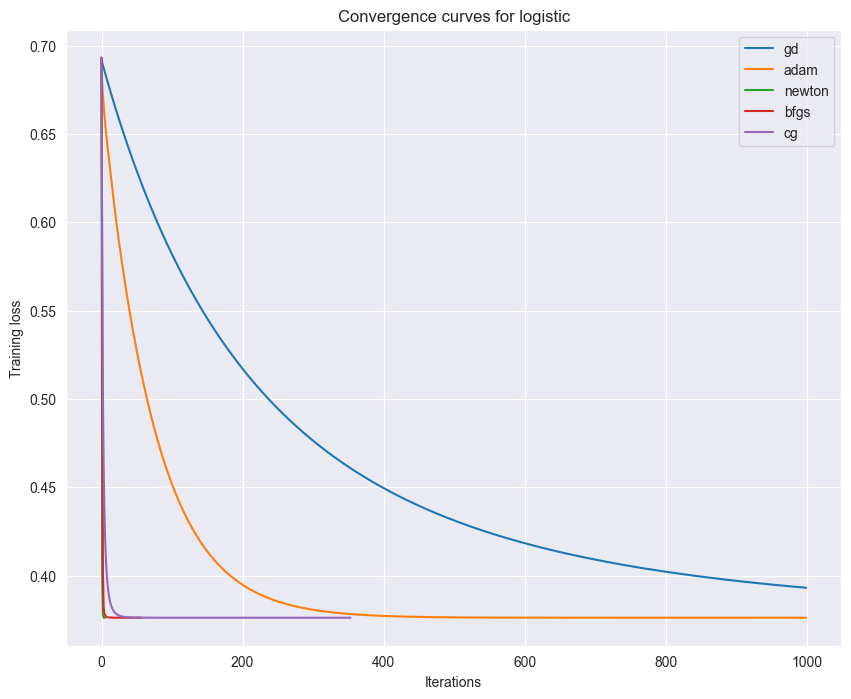

In [42]:
plot_histories(results_df, "logistic")

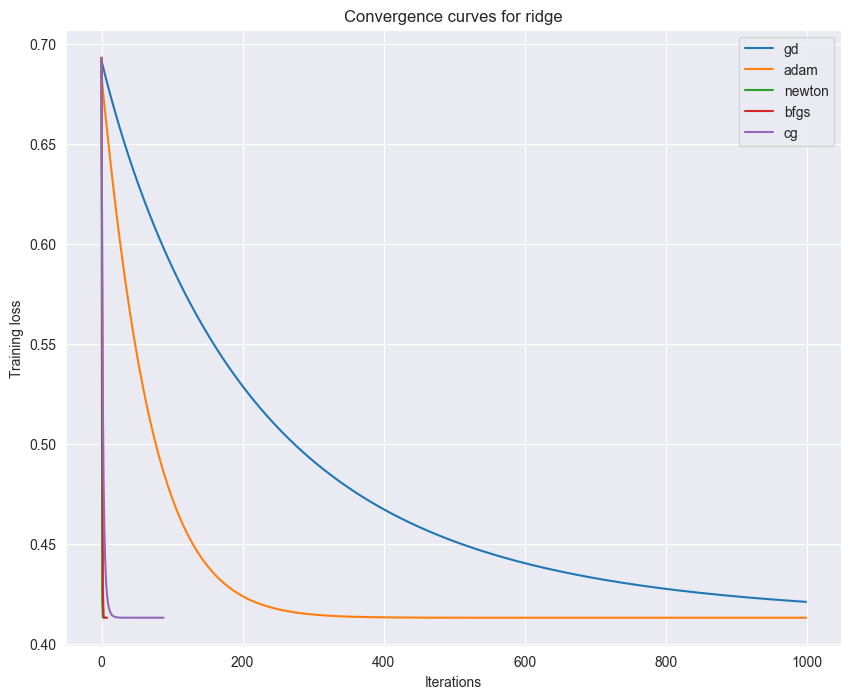

In [43]:
plot_histories(results_df, "ridge")

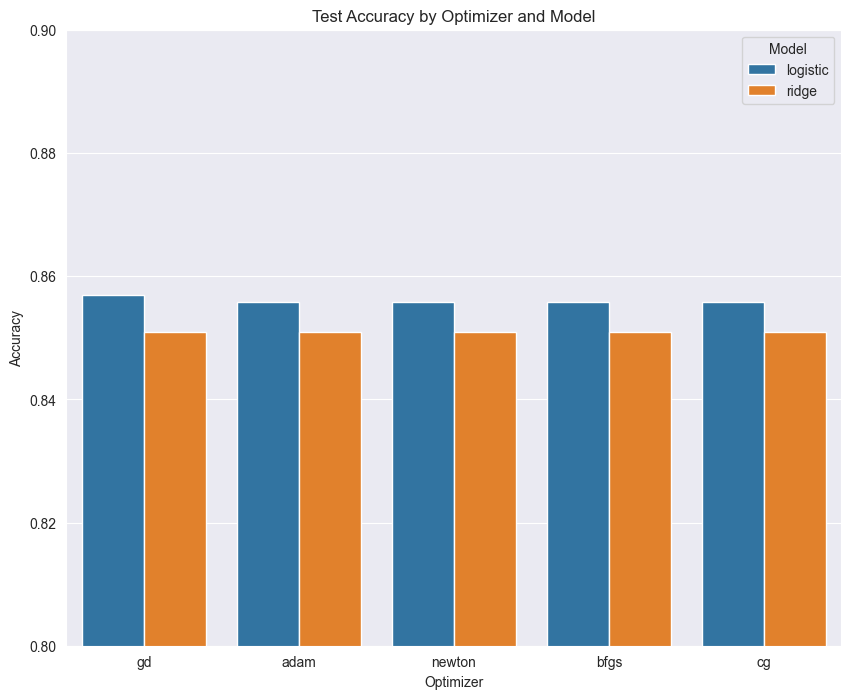

In [45]:
plt.figure(figsize=(10, 8))
sns.barplot(data=results_df, x="Optimizer", y="Test_acc", hue="Model")
plt.title("Test Accuracy by Optimizer and Model")
plt.ylabel("Accuracy")
plt.ylim(0.80, 0.90)
plt.show()

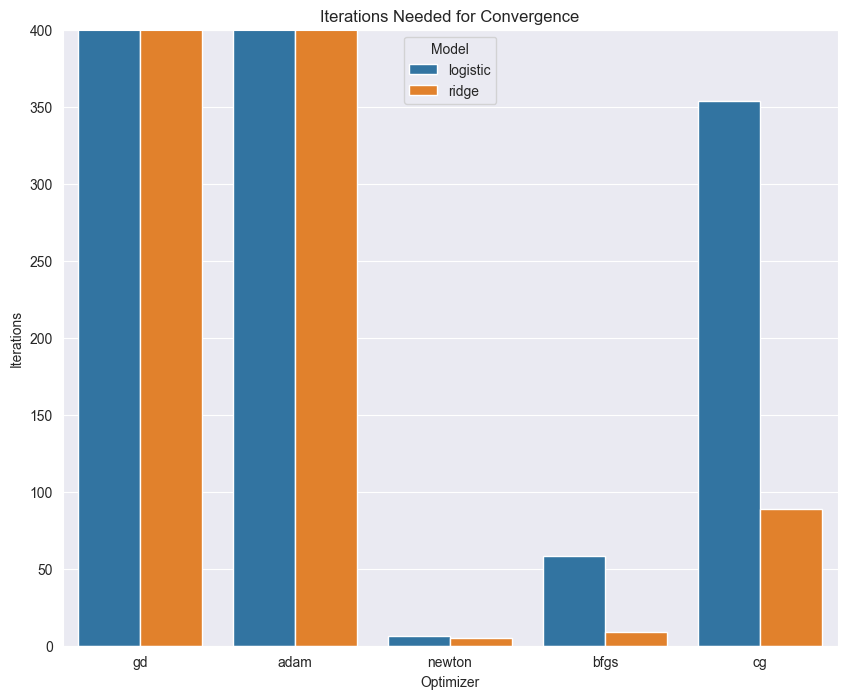

In [48]:
plt.figure(figsize=(10, 8))
sns.barplot(data=results_df, x="Optimizer", y="Iterations", hue="Model")
plt.title("Iterations Needed for Convergence")
plt.ylabel("Iterations")
plt.ylim(0, 400)
plt.show()

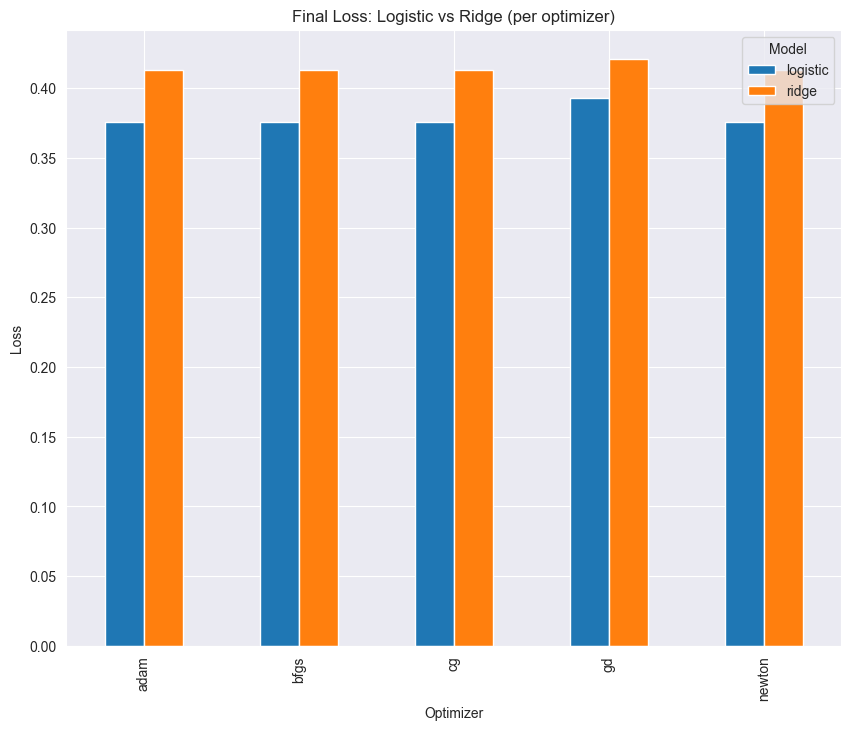

In [50]:
pivot = results_df.pivot(index="Optimizer", columns="Model", values="Final_loss")

pivot.plot(kind="bar", figsize=(10, 8))
plt.title("Final Loss: Logistic vs Ridge (per optimizer)")
plt.ylabel("Loss")
plt.show()

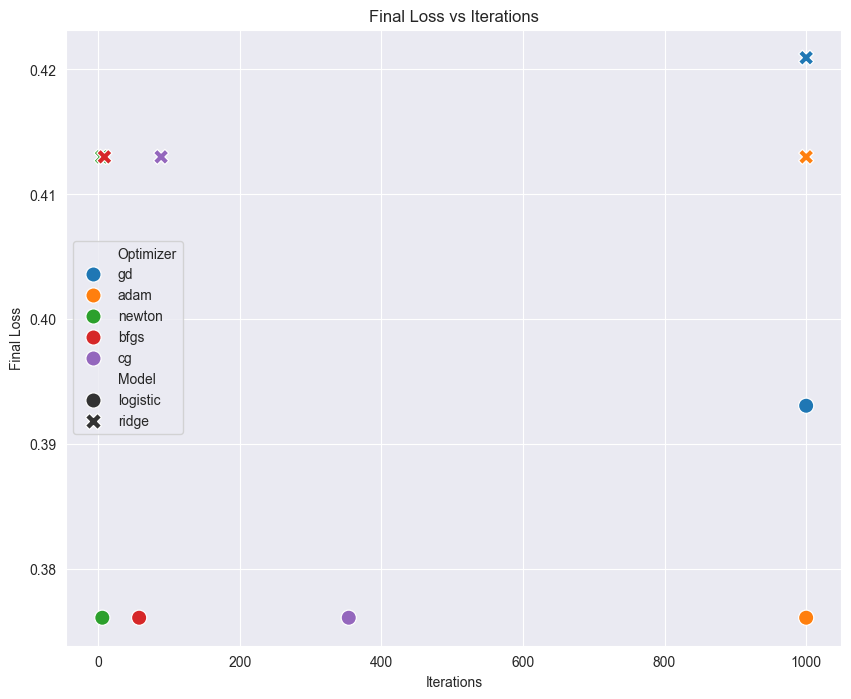

In [49]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=results_df, x="Iterations", y="Final_loss", hue="Optimizer", style="Model", s=120)
plt.title("Final Loss vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Final Loss")
plt.show()


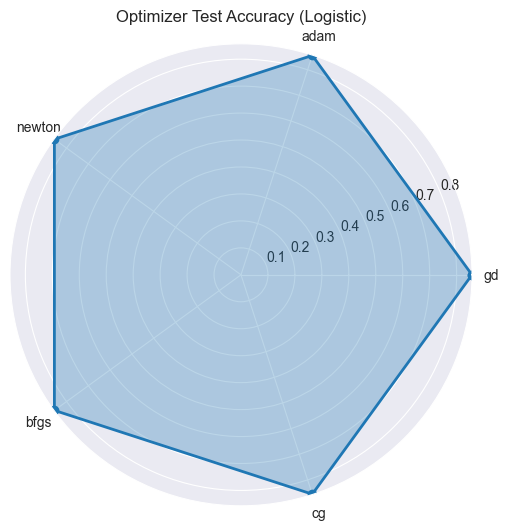

In [51]:
subset = results_df[results_df["Model"] == "logistic"]

labels = subset["Optimizer"].values
stats  = subset["Test_acc"].values

angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)
stats = np.concatenate((stats, [stats[0]]))
angles = np.concatenate((angles, [angles[0]]))

plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)

ax.plot(angles, stats, "o-", linewidth=2)
ax.fill(angles, stats, alpha=0.3)
ax.set_thetagrids(angles[:-1] * 180/np.pi, labels)
plt.title("Optimizer Test Accuracy (Logistic)")
plt.show()

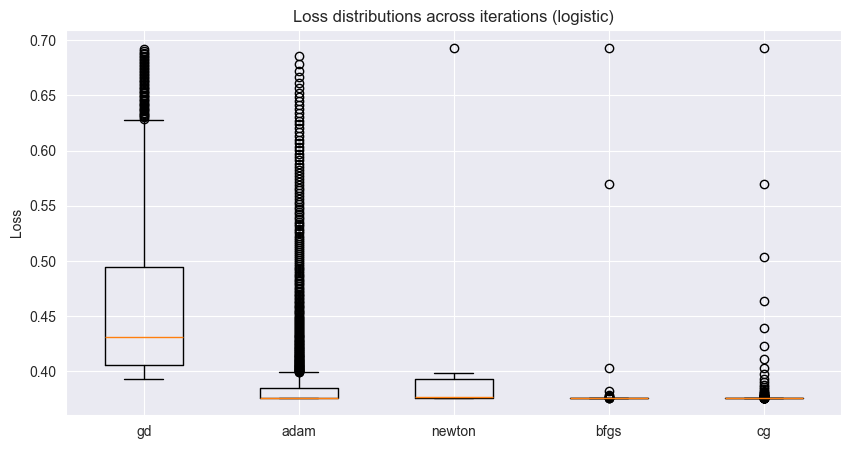

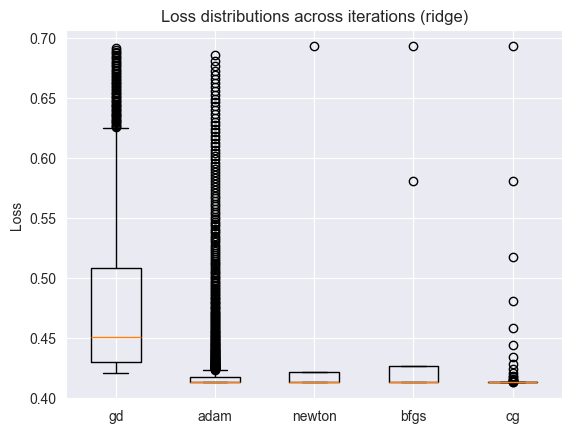

In [53]:
plt.figure(figsize=(10,5))

for model in ["logistic", "ridge"]:
    subset = results_df[results_df["Model"] == model]
    plt.boxplot(subset["History"], tick_labels=subset["Optimizer"])
    plt.title(f"Loss distributions across iterations ({model})")
    plt.ylabel("Loss")
    plt.show()
